# 04 - PCA y preparación de componentes para clustering

Este notebook recibe la salida de `03_preprocessing.ipynb` y reduce sus 12 variables correlacionadas a componentes principales. **No realiza K-Means**: prepara una representación compacta y reproducible para la compañera responsable de ese modelo.

## Resumen ejecutivo

- Entrada: 733 exoplanetas y 12 variables ya procesadas.
- Criterio: conservar al menos el 85 % de la varianza.
- Resultado: 4 componentes que explican el 90,35 %.
- Entrega: PC1–PC4, varianza, loadings, modelo y metadata.

Cada bloque incluye explicación, código comentado y conclusión. El notebook debe ejecutarse después del 03 y siempre en orden.

## Bloque 1. Configuración y contrato con preprocessing

Se definen rutas, las 12 variables en su orden contractual, el identificador y el umbral de varianza. `DATA_ALREADY_SCALED = True` evita aplicar un segundo escalado, porque el notebook 03 ya utilizó `RobustScaler`.

In [1]:
# BLOQUE 1 — Importaciones, rutas, variables y parámetros PCA


from pathlib import Path
import json
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

try:
    from IPython.display import display
except ImportError:
    def display(value):
        print(value)

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 50)

RANDOM_STATE = 42
VARIANCE_THRESHOLD = 0.85

# El notebook 03 ya genera el archivo procesado real.
USE_DEMO_DATA = False

# Ruta esperada desde la raíz del repositorio.
PROCESSED_DATA_PATH = Path("data/processed/exoplanets_preprocessed.csv")

# Contrato de variables definido y exportado por 03_preprocessing.ipynb.
FEATURE_COLUMNS = [
    # Variables planetarias seleccionadas en 01 y 02.
    "pl_orbper",
    "pl_orbsmax",
    "pl_rade",
    "pl_bmasse",
    "pl_orbeccen",
    "pl_insol",
    "pl_eqt",
    # Variables de la estrella anfitriona seleccionadas en 01 y 02.
    "st_teff",
    "st_rad",
    "st_mass",
    "st_met",
    "st_logg",
]

ID_COLUMN = "pl_name"
DATA_ALREADY_SCALED = True

# Integración opcional con el resultado del clustering.
CLUSTER_LABELS_PATH = Path("data/processed/cluster_labels.csv")
CLUSTER_COLUMN = "cluster"

# Los artefactos sintéticos no se exportan para evitar confundirlos con resultados reales.
EXPORT_ARTIFACTS = not USE_DEMO_DATA
OUTPUT_DIR = Path("data/processed/pca")

### Conclusión del bloque 1

PCA recibirá exactamente siete variables planetarias y cinco estelares. `pl_name` se conserva para enlazar resultados, pero no participa en los cálculos. El umbral del 85 % es visible y modificable.

## Bloque 2. Carga de los datos procesados


Se localiza la raíz del proyecto y se carga el CSV generado por el notebook 03. Existe una función de datos sintéticos como salvaguarda técnica, pero `USE_DEMO_DATA = False` obliga a que las conclusiones procedan del dataset real.

In [4]:
# BLOQUE 2A — Localizar las rutas del proyecto


def find_project_root(start: Path | None = None) -> Path:
    # Localiza la raíz del repositorio desde Jupyter o desde nbconvert.
    current = (start or Path.cwd()).resolve()
    candidates = [current, *current.parents]
    for candidate in candidates:
        if (candidate / "README.md").exists() and (candidate / "notebooks").exists():
            return candidate
    raise FileNotFoundError(
        "No se encontró la raíz del repositorio. Ejecuta el notebook dentro de exoplanet-profiler."
    )


PROJECT_ROOT = find_project_root()
processed_path = PROJECT_ROOT / PROCESSED_DATA_PATH
cluster_labels_path = PROJECT_ROOT / CLUSTER_LABELS_PATH
output_dir = PROJECT_ROOT / OUTPUT_DIR

print(f"Raíz del proyecto: {PROJECT_ROOT}")
print(f"Archivo procesado esperado: {processed_path}")

Raíz del proyecto: C:\PROYECTOS_ELE\BOOTCAMP_MODULO3\proyecto2_modulo3\exoplanet-profiler
Archivo procesado esperado: C:\PROYECTOS_ELE\BOOTCAMP_MODULO3\proyecto2_modulo3\exoplanet-profiler\data\processed\exoplanets_preprocessed.csv


In [6]:
# BLOQUE 2B — Cargar los datos reales o el modo de demostración


def make_demo_dataset(n_rows: int = 240, random_state: int = 42) -> pd.DataFrame:
    # Genera las 12 columnas solo como salvaguarda técnica. No produce conclusiones.
    rng = np.random.default_rng(random_state)
    orbital = rng.normal(size=n_rows)
    planet = rng.normal(size=n_rows)
    stellar = rng.normal(size=n_rows)
    noise = lambda scale=0.25: rng.normal(scale=scale, size=n_rows)

    return pd.DataFrame(
        {
            ID_COLUMN: [f"DEMO-{index:03d}" for index in range(1, n_rows + 1)],
            "pl_orbper": 1.10 * orbital + noise(),
            "pl_orbsmax": 0.95 * orbital + noise(),
            "pl_rade": 0.90 * planet + noise(),
            "pl_bmasse": 1.05 * planet + noise(0.35),
            "pl_orbeccen": 0.25 * orbital + noise(0.75),
            "pl_insol": -0.75 * orbital + 0.45 * stellar + noise(),
            "pl_eqt": -0.65 * orbital + 0.55 * stellar + noise(),
            "st_teff": 1.05 * stellar + noise(),
            "st_rad": 0.85 * stellar + noise(),
            "st_mass": 0.90 * stellar + noise(),
            "st_met": 0.30 * stellar + noise(0.60),
            "st_logg": -0.55 * stellar + noise(0.45),
        }
    )


if USE_DEMO_DATA:
    df = make_demo_dataset(random_state=RANDOM_STATE)
    source_mode = "DEMO SINTÉTICA"
else:
    if not processed_path.exists():
        raise FileNotFoundError(
            f"No existe {processed_path}. Revisa PROCESSED_DATA_PATH o activa USE_DEMO_DATA."
        )
    df = pd.read_csv(processed_path)
    source_mode = "DATOS REALES PREPROCESADOS"

print(f"Modo de ejecución: {source_mode}")
print(f"Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas")
display(df.head())

Modo de ejecución: DATOS REALES PREPROCESADOS
Dimensiones: 733 filas x 13 columnas


,pl_name,pl_orbper,pl_orbsmax,pl_rade,pl_bmasse,pl_orbeccen,pl_insol,pl_eqt,st_teff,st_rad,st_mass,st_met,st_logg
0,pi Men c,0.098448,0.036736,-0.297770,-0.337514,-0.306667,0.373146,0.351208,0.356936,0.438559,0.359281,0.115385,-0.149093
1,LHS 3844 b,-1.238849,-0.787171,-0.506409,-0.650181,-0.306667,-0.009179,-0.071279,-1.179258,-1.325836,-1.475050,0.615385,1.570181
2,HD 202772 A b,-0.337676,-0.094580,1.091671,0.685190,-0.106667,1.094757,1.836478,0.590682,1.885430,1.658683,0.661538,-1.492277
3,GJ 143 b,1.447352,1.840134,-0.163612,-0.079911,0.946667,-0.499511,-0.621943,-0.357989,-0.285965,-0.319361,-0.219231,0.342512
4,HD 23472 b,0.885386,0.825188,-0.302482,-0.352776,0.173333,-0.425720,-0.452830,-0.334825,-0.260125,-0.439122,-1.000000,0.119543


### Conclusión del bloque 2

El modo utilizado es **DATOS REALES PREPROCESADOS**. La entrada tiene **733 filas y 13 columnas**: `pl_name` más las 12 características numéricas.

## Bloque 3. Validación del contrato de entrada


PCA no admite valores ausentes y sería incoherente con columnas no numéricas, infinitos o identificadores repetidos. La función de validación comprueba esos requisitos y devuelve únicamente la matriz de características. Después se confirma si hace falta escalar.

In [7]:
# BLOQUE 3A — Validar identificador, columnas, tipos y valores


def validate_pca_input(
    data: pd.DataFrame,
    feature_columns: list[str],
    id_column: str,
) -> pd.DataFrame:
    # Valida que el dataset pueda utilizarse en PCA y devuelve la matriz numérica.
    required_columns = [id_column, *feature_columns]
    missing_columns = [column for column in required_columns if column not in data.columns]
    if missing_columns:
        raise ValueError(f"Faltan columnas requeridas: {missing_columns}")

    if data.empty:
        raise ValueError("El dataset está vacío.")
    if len(feature_columns) < 2:
        raise ValueError("PCA necesita al menos dos variables.")
    if data[id_column].isna().any():
        raise ValueError(f"{id_column} contiene valores nulos.")
    if data[id_column].duplicated().any():
        duplicated = data.loc[data[id_column].duplicated(), id_column].head().tolist()
        raise ValueError(f"{id_column} contiene duplicados, por ejemplo: {duplicated}")

    feature_frame = data.loc[:, feature_columns].copy()
    non_numeric = feature_frame.select_dtypes(exclude=np.number).columns.tolist()
    if non_numeric:
        raise TypeError(f"Las siguientes columnas no son numéricas: {non_numeric}")
    if feature_frame.isna().any().any():
        null_counts = feature_frame.isna().sum()
        raise ValueError(
            "PCA no admite nulos. Columnas afectadas: "
            + str(null_counts[null_counts > 0].to_dict())
        )
    if not np.isfinite(feature_frame.to_numpy()).all():
        raise ValueError("La matriz contiene valores infinitos o no finitos.")
    if len(feature_frame) < len(feature_columns):
        warnings.warn(
            "Hay menos observaciones que variables; revisa si la muestra es suficiente.",
            stacklevel=2,
        )

    return feature_frame


X_input = validate_pca_input(df, FEATURE_COLUMNS, ID_COLUMN)

input_diagnostics = pd.DataFrame(
    {
        "dtype": X_input.dtypes.astype(str),
        "nulos": X_input.isna().sum(),
        "media": X_input.mean(),
        "desviacion_estandar": X_input.std(ddof=0),
        "minimo": X_input.min(),
        "maximo": X_input.max(),
    }
)

display(input_diagnostics.round(4))

,dtype,nulos,media,desviacion_estandar,minimo,maximo
pl_orbper,float64,0,0.1870,0.8559,-1.3875,5.0921
pl_orbsmax,float64,0,0.4632,1.6390,-0.7967,25.2478
pl_rade,float64,0,0.1894,0.5398,-0.7902,1.3177
pl_bmasse,float64,0,0.0539,0.5810,-0.8947,1.6533
pl_orbeccen,float64,0,0.3594,0.9474,-0.3067,5.9680
pl_insol,float64,0,0.0670,0.5213,-1.1764,1.1906
pl_eqt,float64,0,0.1448,0.6644,-0.9839,3.8840
st_teff,float64,0,-0.1466,0.5594,-1.3003,1.6741
st_rad,float64,0,0.0726,0.7425,-1.7954,2.9446
st_mass,float64,0,-0.0395,0.6851,-1.5409,2.0160


In [8]:
# BLOQUE 3B — Confirmar la escala de entrada


if DATA_ALREADY_SCALED:
    X_scaled = X_input.copy()
    scaler_used_here = None
else:
    scaler_used_here = StandardScaler()
    X_scaled = pd.DataFrame(
        scaler_used_here.fit_transform(X_input),
        columns=FEATURE_COLUMNS,
        index=X_input.index,
    )
    warnings.warn(
        "El escalado se ha realizado en este notebook. Documenta esta decisión con el miembro 2.",
        stacklevel=2,
    )

scale_check = pd.DataFrame(
    {
        "media": X_scaled.mean(),
        "desviacion_estandar": X_scaled.std(ddof=0),
    }
)
display(scale_check.round(4))

if DATA_ALREADY_SCALED and (X_scaled.std(ddof=0) == 0).any():
    constant_columns = X_scaled.columns[X_scaled.std(ddof=0) == 0].tolist()
    raise ValueError(f"Hay variables constantes que deben retirarse: {constant_columns}")

,media,desviacion_estandar
pl_orbper,0.1870,0.8559
pl_orbsmax,0.4632,1.6390
pl_rade,0.1894,0.5398
pl_bmasse,0.0539,0.5810
pl_orbeccen,0.3594,0.9474
pl_insol,0.0670,0.5213
pl_eqt,0.1448,0.6644
st_teff,-0.1466,0.5594
st_rad,0.0726,0.7425
st_mass,-0.0395,0.6851


### Conclusión del bloque 3

Las 12 variables son numéricas, no contienen nulos ni infinitos y ninguna es constante. No se vuelve a escalar: se utiliza directamente la salida robusta del preprocessing.

## Bloque 4. Ajuste de PCA y selección de componentes


Primero se ajusta un PCA completo para conocer la varianza de todas las componentes. `np.searchsorted` localiza el primer punto donde la varianza acumulada alcanza el 85 %. Después se reajusta PCA conservando solo ese número de componentes y se calculan los scores de cada planeta.

In [9]:
# BLOQUE 4 — Ajustar PCA y calcular los scores


full_pca = PCA(svd_solver="full")
full_pca.fit(X_scaled)

explained_variance = pd.DataFrame(
    {
        "componente": np.arange(1, full_pca.n_components_ + 1),
        "varianza_explicada": full_pca.explained_variance_ratio_,
        "varianza_acumulada": np.cumsum(full_pca.explained_variance_ratio_),
    }
)

n_components = int(
    np.searchsorted(
        explained_variance["varianza_acumulada"].to_numpy(),
        VARIANCE_THRESHOLD,
    )
    + 1
)

pca_model = PCA(n_components=n_components, svd_solver="full")
scores_array = pca_model.fit_transform(X_scaled)
component_names = [f"PC{index}" for index in range(1, n_components + 1)]

scores_df = pd.DataFrame(scores_array, columns=component_names, index=df.index)
scores_df.insert(0, ID_COLUMN, df[ID_COLUMN].values)

retained_variance = float(pca_model.explained_variance_ratio_.sum())

print(f"Umbral configurado: {VARIANCE_THRESHOLD:.0%}")
print(f"Componentes retenidos: {n_components}")
print(f"Varianza explicada retenida: {retained_variance:.2%}")
display(explained_variance.round(4))

Umbral configurado: 85%
Componentes retenidos: 4
Varianza explicada retenida: 90.35%


,componente,varianza_explicada,varianza_acumulada
0,1,0.4465,0.4465
1,2,0.2956,0.7421
2,3,0.0941,0.8362
3,4,0.0674,0.9035
4,5,0.0350,0.9385
5,6,0.0302,0.9687
6,7,0.0182,0.9869
7,8,0.0040,0.9908
8,9,0.0034,0.9943
9,10,0.0032,0.9975


### Conclusión del bloque 4

Tres componentes explican el 83,62 %, por debajo del objetivo. Con **4 componentes se alcanza el 90,35 %**, así que PC1–PC4 constituyen la representación que se entregará al clustering.

#### Varianza explicada por el PCA

Los resultados muestran que las primeras componentes concentran la mayor parte de la información del conjunto de datos.

La primera componente principal explica aproximadamente el **44,65 %** de la varianza total, mientras que la segunda explica un **29,56 %** adicional. En conjunto, las dos primeras componentes acumulan un **74,21 %** de la información original.

Al incorporar la tercera componente, la varianza acumulada alcanza el **83,62 %**, y con la cuarta componente se supera el **90 %**, llegando concretamente al **90,35 %**.

A partir de la quinta componente, la aportación individual disminuye considerablemente. Las últimas componentes explican porcentajes muy reducidos de varianza, lo que indica que contienen poca información adicional respecto a las primeras.

Por tanto, una reducción a **4 componentes principales** parece una opción adecuada, ya que permite conservar más del **90 % de la varianza** utilizando únicamente 4 variables en lugar de las 12 originales.

Si se quisiera una reducción más agresiva para facilitar la visualización o simplificar el modelo, podrían utilizarse 2 o 3 componentes, aunque se conservaría menos información:

* 2 componentes: **74,21 %** de varianza acumulada.
* 3 componentes: **83,62 %** de varianza acumulada.
* 4 componentes: **90,35 %** de varianza acumulada.

En conclusión, el PCA permite reducir de forma significativa la dimensionalidad del dataset, manteniendo la mayor parte de su información y eliminando componentes que aportan una cantidad mínima de varianza.


## Bloque 5. Visualización de la varianza explicada


El gráfico de barras muestra la aportación individual de cada componente y la curva muestra la acumulada. Las líneas de referencia permiten ver el umbral y el punto de corte elegido por el código.

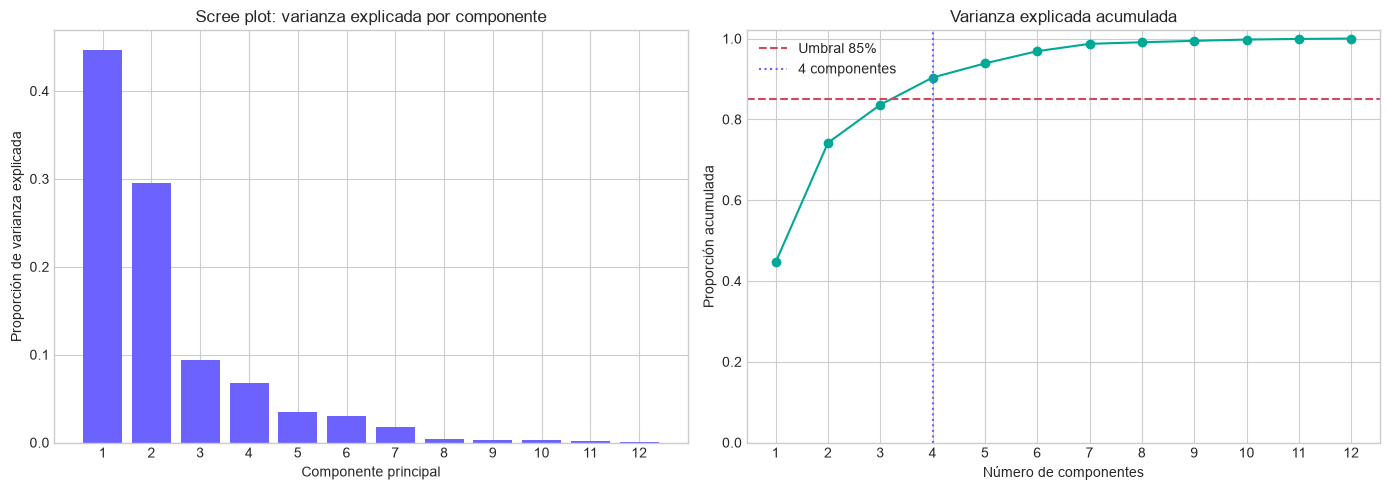

In [10]:
# BLOQUE 5 — Dibujar la varianza individual y acumulada


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(
    explained_variance["componente"],
    explained_variance["varianza_explicada"],
    color="#6C63FF",
)
axes[0].set(
    title="Scree plot: varianza explicada por componente",
    xlabel="Componente principal",
    ylabel="Proporción de varianza explicada",
)
axes[0].set_xticks(explained_variance["componente"])

axes[1].plot(
    explained_variance["componente"],
    explained_variance["varianza_acumulada"],
    marker="o",
    color="#00A896",
)
axes[1].axhline(
    VARIANCE_THRESHOLD,
    color="#D1495B",
    linestyle="--",
    label=f"Umbral {VARIANCE_THRESHOLD:.0%}",
)
axes[1].axvline(n_components, color="#6C63FF", linestyle=":", label=f"{n_components} componentes")
axes[1].set(
    title="Varianza explicada acumulada",
    xlabel="Número de componentes",
    ylabel="Proporción acumulada",
    ylim=(0, 1.02),
)
axes[1].set_xticks(explained_variance["componente"])
axes[1].legend()

plt.tight_layout()
plt.show()

### Conclusión del bloque 5

PC1 explica **44,65 %**, PC2 **29,56 %**, PC3 **9,41 %** y PC4 **6,74 %**. Las cuatro suman **90,35 %**. La caída después de las dos primeras muestra que gran parte de la estructura está concentrada, aunque PC3 y PC4 conservan información necesaria para superar el umbral.

## Bloque 6. Loadings e interpretación física


Los *loadings* son los pesos de las variables originales dentro de cada componente. El mapa de calor permite comparar signo y magnitud; la tabla adicional selecciona las tres contribuciones absolutas más fuertes de cada componente. El signo global puede invertirse sin alterar la solución.

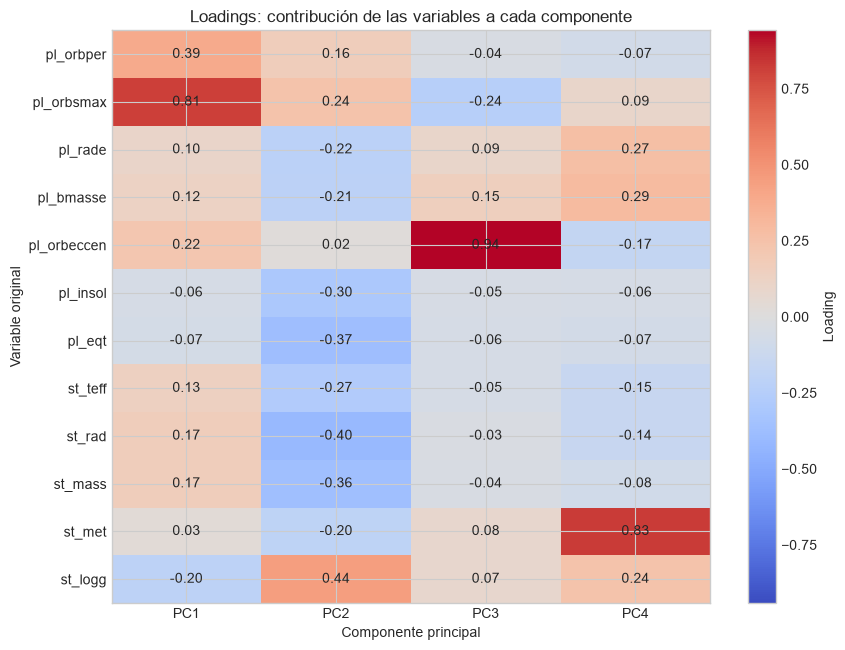

,PC1,PC2,PC3,PC4
pl_orbper,0.386,0.162,-0.038,-0.074
pl_orbsmax,0.810,0.242,-0.240,0.093
pl_rade,0.098,-0.218,0.090,0.265
pl_bmasse,0.124,-0.206,0.152,0.292
pl_orbeccen,0.219,0.021,0.941,-0.165
pl_insol,-0.057,-0.295,-0.051,-0.057
pl_eqt,-0.066,-0.369,-0.058,-0.068
st_teff,0.133,-0.267,-0.054,-0.146
st_rad,0.168,-0.405,-0.033,-0.143
st_mass,0.165,-0.362,-0.040,-0.083


In [11]:
# BLOQUE 6A — Calcular y visualizar los loadings


loadings_df = pd.DataFrame(
    pca_model.components_.T,
    index=FEATURE_COLUMNS,
    columns=component_names,
)

fig_width = max(8, 1.2 * n_components + 4)
fig, ax = plt.subplots(figsize=(fig_width, max(5, 0.55 * len(FEATURE_COLUMNS))))
max_abs_loading = max(0.01, float(np.abs(loadings_df.to_numpy()).max()))
image = ax.imshow(
    loadings_df.to_numpy(),
    cmap="coolwarm",
    vmin=-max_abs_loading,
    vmax=max_abs_loading,
    aspect="auto",
)
ax.set_xticks(np.arange(len(loadings_df.columns)), labels=loadings_df.columns)
ax.set_yticks(np.arange(len(loadings_df.index)), labels=loadings_df.index)
for row in range(loadings_df.shape[0]):
    for column in range(loadings_df.shape[1]):
        ax.text(column, row, f"{loadings_df.iloc[row, column]:.2f}", ha="center", va="center")
ax.set_title("Loadings: contribución de las variables a cada componente")
ax.set_xlabel("Componente principal")
ax.set_ylabel("Variable original")
fig.colorbar(image, ax=ax, label="Loading")
fig.tight_layout()
plt.show()

display(loadings_df.round(3))

In [12]:
# BLOQUE 6B — Extraer las variables dominantes


def strongest_loadings(loadings: pd.DataFrame, top_n: int = 3) -> pd.DataFrame:
    # Devuelve las variables con mayor loading absoluto para cada componente.
    records = []
    for component in loadings.columns:
        ranked = loadings[component].abs().nlargest(min(top_n, len(loadings)))
        for rank, feature in enumerate(ranked.index, start=1):
            records.append(
                {
                    "componente": component,
                    "posicion": rank,
                    "variable": feature,
                    "loading": loadings.loc[feature, component],
                    "loading_absoluto": abs(loadings.loc[feature, component]),
                }
            )
    return pd.DataFrame(records)


top_loadings_df = strongest_loadings(loadings_df, top_n=3)
display(top_loadings_df.round(3))

,componente,posicion,variable,loading,loading_absoluto
0,PC1,1,pl_orbsmax,0.810,0.810
1,PC1,2,pl_orbper,0.386,0.386
2,PC1,3,pl_orbeccen,0.219,0.219
3,PC2,1,st_logg,0.442,0.442
4,PC2,2,st_rad,-0.405,0.405
5,PC2,3,pl_eqt,-0.369,0.369
6,PC3,1,pl_orbeccen,0.941,0.941
7,PC3,2,pl_orbsmax,-0.240,0.240
8,PC3,3,pl_bmasse,0.152,0.152
9,PC4,1,st_met,0.830,0.830


### Conclusión del bloque 6

- **PC1**: dimensión orbital, dominada por `pl_orbsmax` y `pl_orbper`.
- **PC2**: gradiente estelar-térmico, con `st_logg` frente a `st_rad`, `pl_eqt` y `st_mass`.
- **PC3**: dimensión de excentricidad, dominada por `pl_orbeccen`.
- **PC4**: información de metalicidad, dominada por `st_met`, con apoyo de masa y radio planetarios.


El análisis de los *loadings* permite identificar qué variables originales tienen mayor influencia en cada componente principal y, por tanto, interpretar el significado físico de las nuevas dimensiones creadas por el PCA.

### PC1: configuración orbital del planeta

La primera componente está dominada principalmente por:

* `pl_orbsmax` — semieje mayor de la órbita: **0.810**
* `pl_orbper` — periodo orbital: **0.386**
* `pl_orbeccen` — excentricidad orbital: **0.219**

El elevado peso de `pl_orbsmax` indica que PC1 representa fundamentalmente la **dimensión y extensión de la órbita del planeta**. Los planetas con valores altos en esta componente tenderán a presentar órbitas más amplias y, generalmente, periodos orbitales más largos.

Esta componente puede interpretarse como una dimensión de **configuración o escala orbital**.

### PC2: características de la estrella y entorno térmico

Las variables con mayor influencia son:

* `st_logg` — gravedad superficial de la estrella: **0.442**
* `st_rad` — radio estelar: **−0.405**
* `pl_eqt` — temperatura de equilibrio del planeta: **−0.369**

Los signos opuestos indican que esta componente contrapone estrellas con mayor gravedad superficial frente a estrellas de mayor radio y planetas con temperaturas de equilibrio más elevadas.

De forma general, valores altos de PC2 estarían asociados con una mayor gravedad superficial estelar y con menores valores de radio estelar y temperatura planetaria.

Esta componente puede interpretarse como una dimensión de **estructura estelar y condiciones térmicas del sistema**.

### PC3: forma de la órbita

La tercera componente está claramente dominada por:

* `pl_orbeccen` — excentricidad orbital: **0.941**

El resto de variables presentan una contribución mucho menor:

* `pl_orbsmax`: **−0.240**
* `pl_bmasse`: **0.152**

Por tanto, PC3 representa principalmente la **excentricidad de la órbita**, es decir, hasta qué punto la trayectoria del planeta se aleja de una órbita circular.

Los planetas con valores altos en PC3 tenderán a presentar órbitas más elípticas o excéntricas.

### PC4: composición estelar y tamaño del planeta

Las variables más relevantes son:

* `st_met` — metalicidad de la estrella: **0.830**
* `pl_bmasse` — masa planetaria: **0.292**
* `pl_rade` — radio planetario: **0.265**

La cuarta componente está dominada por la metalicidad estelar, aunque también recoge información relacionada con el tamaño físico del planeta.

Esta componente podría interpretarse como una dimensión de **composición química de la estrella y características físicas del planeta**.

### Interpretación global

Las cuatro componentes seleccionadas resumen diferentes aspectos de los sistemas planetarios:

1. **PC1:** escala y configuración orbital.
2. **PC2:** estructura de la estrella y entorno térmico del planeta.
3. **PC3:** excentricidad o forma de la órbita.
4. **PC4:** metalicidad estelar y tamaño planetario.

La primera y la tercera componente contienen información principalmente orbital, mientras que la segunda y la cuarta incorporan características de la estrella anfitriona y propiedades físicas de los planetas.

Debe tenerse en cuenta que el signo de los *loadings* puede invertirse sin cambiar el significado matemático del PCA. Por ello, la importancia de cada variable se determina principalmente mediante el valor absoluto del *loading*, mientras que el signo permite estudiar relaciones opuestas entre variables dentro de una misma componente.


## Bloque 7. Proyección bidimensional



PC1 y PC2 se representan para observar la estructura general. Si más adelante existe un archivo de etiquetas, se une mediante `pl_name` y se colorean los puntos. La unión por identificador evita asignar clusters incorrectos si cambia el orden de las filas.

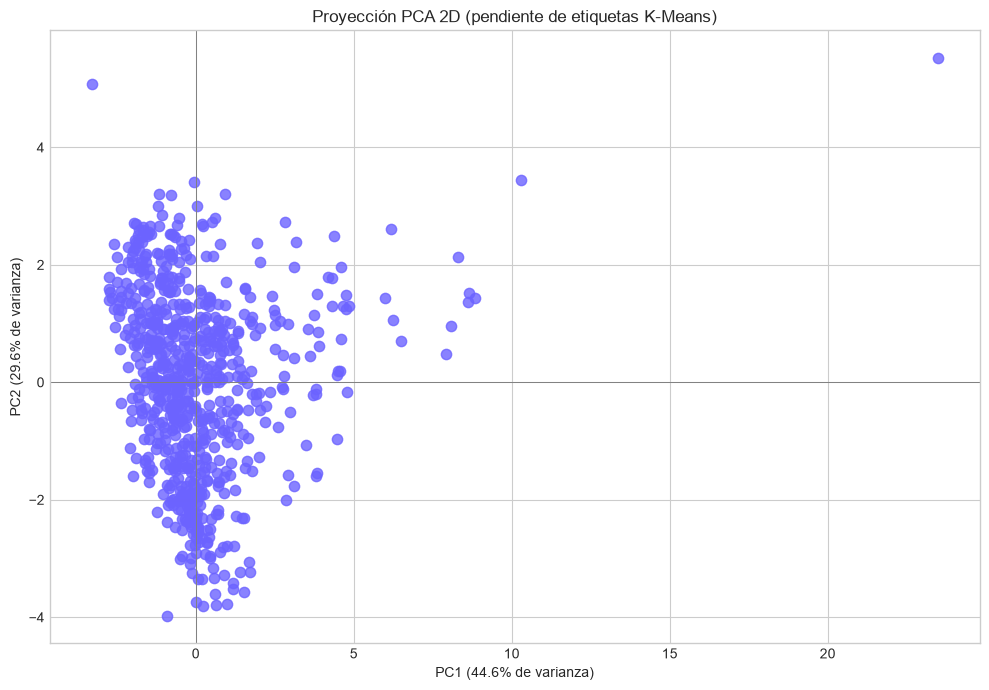

In [13]:
# BLOQUE 7 — Representar PC1 frente a PC2


plot_df = scores_df.copy()
plot_hue_column = None

# Cuando la responsable de K-Means entregue las etiquetas definitivas,
# el notebook las añadirá por pl_name para colorear la proyección.
if not USE_DEMO_DATA and cluster_labels_path.exists():
    cluster_labels = pd.read_csv(cluster_labels_path)
    required_cluster_columns = {ID_COLUMN, CLUSTER_COLUMN}
    missing_cluster_columns = required_cluster_columns.difference(cluster_labels.columns)
    if missing_cluster_columns:
        raise ValueError(
            f"El archivo de clusters no contiene: {sorted(missing_cluster_columns)}"
        )
    plot_df = plot_df.merge(
        cluster_labels[[ID_COLUMN, CLUSTER_COLUMN]],
        on=ID_COLUMN,
        how="left",
        validate="one_to_one",
    )
    plot_hue_column = CLUSTER_COLUMN

fig, ax = plt.subplots(figsize=(10, 7))

if plot_hue_column is not None:
    for cluster_value, cluster_data in plot_df.groupby(plot_hue_column, dropna=False):
        ax.scatter(
            cluster_data["PC1"],
            cluster_data["PC2"],
            alpha=0.8,
            s=55,
            label=str(cluster_value),
        )
    ax.legend(title=plot_hue_column)
    plot_title = "Proyección PCA 2D por cluster"
else:
    ax.scatter(plot_df["PC1"], plot_df["PC2"], color="#6C63FF", alpha=0.8, s=55)
    plot_title = "Proyección PCA 2D (pendiente de etiquetas K-Means)"

ax.axhline(0, color="grey", linewidth=0.7)
ax.axvline(0, color="grey", linewidth=0.7)
ax.set_title(plot_title)
ax.set_xlabel(f"PC1 ({pca_model.explained_variance_ratio_[0]:.1%} de varianza)")
ax.set_ylabel(f"PC2 ({pca_model.explained_variance_ratio_[1]:.1%} de varianza)")
plt.tight_layout()
plt.show()

### Conclusión del bloque 7

La proyección 2D resume el **74,21 %** de la varianza. Es útil para explorar y comunicar, pero no sustituye las cuatro componentes que recibirá K-Means. La ausencia actual de colores indica que todavía no se han incorporado etiquetas definitivas.

## Bloque 8. Proyección tridimensional


Se añade PC3 cuando existen al menos tres componentes. Esta vista ayuda a observar la dimensión dominada por excentricidad, aunque sigue siendo una simplificación del espacio final de cuatro dimensiones.

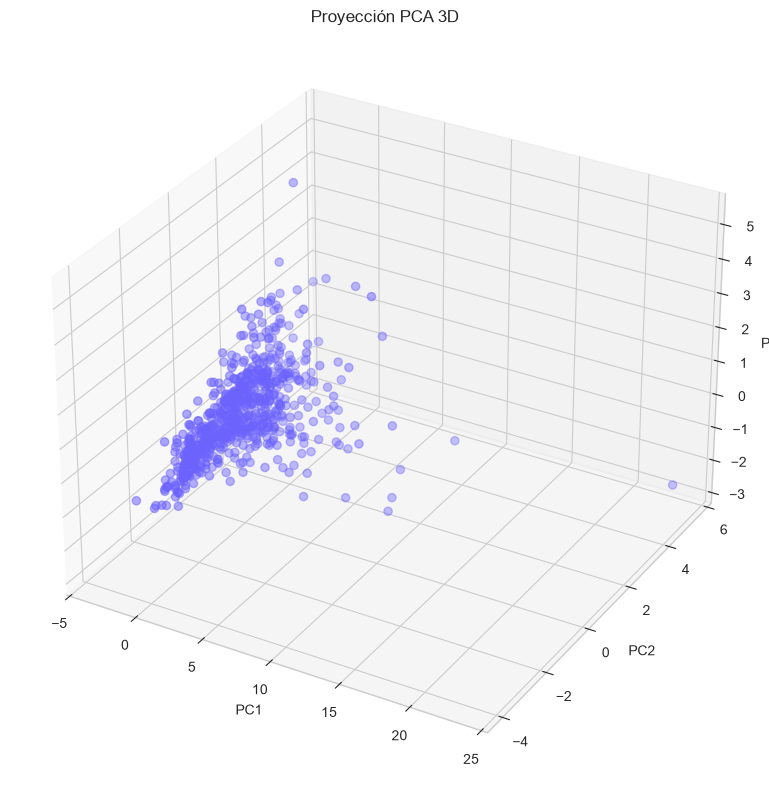

In [14]:
# BLOQUE 8 — Representar PC1, PC2 y PC3


if n_components >= 3:
    fig = plt.figure(figsize=(11, 8))
    ax = fig.add_subplot(111, projection="3d")

    if plot_hue_column is not None and plot_hue_column in plot_df.columns:
        categories = sorted(plot_df[plot_hue_column].dropna().unique())
        color_map = plt.get_cmap("tab10")
        palette = {
            category: color_map(index % 10)
            for index, category in enumerate(categories)
        }
        colors = plot_df[plot_hue_column].map(palette)
    else:
        colors = "#6C63FF"

    ax.scatter(
        plot_df["PC1"],
        plot_df["PC2"],
        plot_df["PC3"],
        c=colors,
        alpha=0.75,
        s=35,
    )
    ax.set(
        title="Proyección PCA 3D",
        xlabel="PC1",
        ylabel="PC2",
        zlabel="PC3",
    )
    plt.tight_layout()
    plt.show()
else:
    print("El modelo ha retenido menos de tres componentes; no se genera la proyección 3D.")

### Conclusión del bloque 8

La proyección 3D representa el **83,62 %** de la varianza. Mejora la visión respecto a 2D, pero todavía omite PC4; por ello se utiliza solo como apoyo visual y no como entrada reducida definitiva.

## Bloque 9. Comprobaciones de consistencia


Las aserciones verifican dimensiones, identificadores, ausencia de nulos, forma de los loadings y cumplimiento del umbral. También se calcula el error medio de reconstrucción como medida descriptiva de la información descartada.

In [15]:
# BLOQUE 9 — Validar scores, loadings, varianza y reconstrucción


assert scores_df.shape == (len(df), n_components + 1)
assert scores_df[ID_COLUMN].is_unique
assert not scores_df[component_names].isna().any().any()
assert loadings_df.shape == (len(FEATURE_COLUMNS), n_components)
assert 0 < retained_variance <= 1
assert retained_variance >= VARIANCE_THRESHOLD or n_components == full_pca.n_components_

reconstruction = pca_model.inverse_transform(scores_df[component_names])
reconstruction_mse = float(np.mean((X_scaled.to_numpy() - reconstruction) ** 2))

checks = pd.Series(
    {
        "observaciones": len(scores_df),
        "variables_de_entrada": len(FEATURE_COLUMNS),
        "componentes_retenidos": n_components,
        "varianza_retenida": retained_variance,
        "error_medio_reconstruccion": reconstruction_mse,
    },
    name="resultado",
)
display(checks.to_frame().round(6))
print("Comprobaciones superadas.")

,resultado
observaciones,733.000000
variables_de_entrada,12.000000
componentes_retenidos,4.000000
varianza_retenida,0.903540
error_medio_reconstruccion,0.066834


Comprobaciones superadas.


### Conclusión del bloque 9

Todas las pruebas pasan: **733 observaciones, 12 variables y 4 componentes**, con varianza retenida de 0,903540 y error medio de reconstrucción de **0,066834**.

## Bloque 10. Exportación y entrega al equipo


Se guardan scores, varianza, loadings, modelo y metadata. La metadata documenta el orden de entrada y evita que otro miembro aplique PCA con columnas intercambiadas. Si llegan etiquetas de K-Means, solo se integrarán para visualizar y perfilar.

In [16]:
# BLOQUE 10 — Exportar los artefactos reproducibles de PCA


metadata = {
    "source_mode": source_mode,
    "input_path": str(processed_path),
    "id_column": ID_COLUMN,
    "feature_columns": FEATURE_COLUMNS,
    "data_already_scaled": DATA_ALREADY_SCALED,
    "variance_threshold": VARIANCE_THRESHOLD,
    "n_components": n_components,
    "retained_variance": retained_variance,
    "random_state": RANDOM_STATE,
}

if EXPORT_ARTIFACTS:
    output_dir.mkdir(parents=True, exist_ok=True)
    scores_df.to_csv(output_dir / "pca_scores.csv", index=False)
    explained_variance.to_csv(output_dir / "pca_explained_variance.csv", index=False)
    loadings_df.to_csv(output_dir / "pca_loadings.csv", index_label="variable")
    joblib.dump(pca_model, output_dir / "pca_model.joblib")
    if scaler_used_here is not None:
        joblib.dump(scaler_used_here, output_dir / "pca_local_scaler.joblib")
    (output_dir / "pca_metadata.json").write_text(
        json.dumps(metadata, ensure_ascii=False, indent=2),
        encoding="utf-8",
    )
    print(f"Artefactos exportados en: {output_dir}")
else:
    print("Exportación desactivada: la ejecución usa datos de demostración.")

display(pd.Series(metadata, name="valor").to_frame())

Artefactos exportados en: C:\PROYECTOS_ELE\BOOTCAMP_MODULO3\proyecto2_modulo3\exoplanet-profiler\data\processed\pca


,valor
source_mode,DATOS REALES PREPROCESADOS
input_path,C:\PROYECTOS_ELE\BOOTCAMP_MODULO3\proyecto2_mo...
id_column,pl_name
feature_columns,"[pl_orbper, pl_orbsmax, pl_rade, pl_bmasse, pl..."
data_already_scaled,True
variance_threshold,0.85
n_components,4
retained_variance,0.90354
random_state,42


### Conclusión del bloque 10


La responsable de K-Means debe utilizar `data/processed/pca/pca_scores.csv`, con `pl_name` y **PC1–PC4**. 
data/processed/pca/pca_scores.csv

Este archivo contiene el identificador de cada planeta, pl_name, junto con las cuatro componentes principales obtenidas mediante PCA:

PC1, PC2, PC3 y PC4

La columna pl_name se utiliza únicamente para identificar cada planeta, pero no debe introducirse en K-Means porque es una variable de texto. El modelo debe entrenarse solo con las cuatro componentes principales:

X_kmeans = pca_scores[["PC1", "PC2", "PC3", "PC4"]]

Estas cuatro componentes resumen la información contenida en las 12 variables originales y conservan aproximadamente el 90,35 % de la varianza total.




## Limitaciones del análisis

### Elevado número de valores imputados en `pl_insol`

La variable `pl_insol`, que representa la radiación recibida por el planeta, contenía una cantidad elevada de valores ausentes.

Por este motivo, muchos de sus valores han sido estimados mediante imputación y no proceden directamente de una observación original.

Esto no significa que la variable no pueda utilizarse, pero sus resultados deben interpretarse con precaución, ya que introduce un mayor grado de incertidumbre en el análisis.

---

### Poca representación de los registros de 2026

Después del proceso de limpieza y selección de datos, la muestra conserva pocos planetas correspondientes al año 2026.

Esto implica que los descubrimientos más recientes están menos representados y que el modelo describe principalmente los patrones de los años con mayor número de observaciones.

Por tanto, no se puede afirmar que la muestra represente de forma equilibrada todos los años de descubrimiento.

---

### PCA solo describe variación lineal

PCA genera nuevas componentes mediante combinaciones lineales de las variables originales.

Esto permite reducir la dimensionalidad y resumir gran parte de la información, pero puede no capturar correctamente relaciones curvas, complejas o no lineales entre las variables.

Por ello, PCA representa principalmente la estructura lineal del dataset y puede perder parte de la información asociada a patrones no lineales.

---

### Una separación visual no garantiza clusters válidos

La representación de los planetas utilizando las componentes principales puede mostrar zonas aparentemente separadas.

Sin embargo, observar grupos en una gráfica no demuestra por sí solo que existan clusters reales, estables y útiles.

La separación visual puede estar influida por:

* valores extremos;
* la elección de las componentes representadas;
* el solapamiento existente en otras dimensiones;
* la tendencia de K-Means a dividir los datos incluso cuando no existe una estructura clara de grupos.

Por este motivo, la elección del número de clusters debe apoyarse en diferentes criterios:

* método del codo;
* `silhouette_score`;
* tamaño de los clusters;
* estabilidad de los resultados;
* interpretación física de los grupos obtenidos.

En conclusión, la representación gráfica puede sugerir la existencia de posibles grupos, pero las métricas y la interpretación de las características de los planetas deben confirmar que los clusters son coherentes y útiles.
